In [1]:
import os, cv2, torch, random, shutil, warnings
import numpy as np
import pandas as pd
import xml.etree.ElementTree as ET
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from tqdm import tqdm
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (confusion_matrix, f1_score,
                              classification_report, roc_auc_score)
import seaborn as sns

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, Subset
import torchvision.transforms as T
import torchvision.models as models



In [2]:
warnings.filterwarnings("ignore")
torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

In [3]:
# ── Paths (identical to RCNN and DenseNet notebooks) ──────────────────────
DATASET_PATH    = "/kaggle/input/datasets/abdullahelafifi/main-data/Main data"
ANNOTATIONS_DIR = os.path.join(DATASET_PATH, "Annotations")
IMAGES_DIR      = os.path.join(DATASET_PATH, "JPEGImages")
SPLITS_DIR      = os.path.join(DATASET_PATH, "ImageSets/Main")

# CHANGE: renamed dirs to resnet_ prefix to avoid mixing with DenseNet outputs
CROP_DIR        = "/kaggle/working/resnet_crops"
SAVE_DIR        = "/kaggle/working/resnet_models"
os.makedirs(CROP_DIR, exist_ok=True)
os.makedirs(SAVE_DIR, exist_ok=True)

In [4]:
# ── Preprocessing constants (IDENTICAL to RCNN + DenseNet — DO NOT CHANGE) ─

CLAHE_CLIP     = 2.0
CLAHE_GRID     = (8, 8)
CROP_MARGIN    = 30          
RESIZE_SIZE    = 224         

LABEL_MAP      = {"0": 0, "1": 1}   
CLASS_NAMES    = ["benign", "malignant"]

DEVICE         = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cuda


In [5]:
# ── Hyperparameters ────────────────────────────────────────────────────────
NUM_CLASSES  = 2
BATCH_SIZE   = 32
NUM_EPOCHS   = 30          # Higher ceiling — early stopping will decide actual end
LR           = 3e-4        # Slightly lower LR for ResNet fine-tuning stability
WEIGHT_DECAY = 1e-4        # L2 regularisation — same as DenseNet fix applied earlier
K_FOLDS      = 3
PATIENCE     = 10        # CHANGE: increased from 5 — gives model room to recover                  
NUM_WORKERS  = 2

In [6]:
# ── Preprocessing (IDENTICAL to DenseNet — CLAHE + unsharp mask) ──────────

def preprocess_image(img_bgr):
    # Step 1: CLAHE on L channel — enhances local contrast in ultrasound
    lab       = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2LAB)
    l, a, b   = cv2.split(lab)
    clahe     = cv2.createCLAHE(clipLimit=CLAHE_CLIP, tileGridSize=CLAHE_GRID)
    l_clahe   = clahe.apply(l)
    img_clahe = cv2.cvtColor(cv2.merge([l_clahe, a, b]), cv2.COLOR_LAB2BGR)

    # Step 2: Mild unsharp masking — enhances nodule margin definition
    blurred   = cv2.GaussianBlur(img_clahe, (0, 0), sigmaX=2)
    sharpened = cv2.addWeighted(img_clahe, 1.3, blurred, -0.3, 0)
    return sharpened

def parse_xml(xml_path):
    tree  = ET.parse(xml_path)
    root  = tree.getroot()
    items = []
    for obj in root.findall("object"):
        cls   = LABEL_MAP.get(obj.find("name").text.strip(), -1)
        xmin  = int(obj.find("bndbox/xmin").text)
        ymin  = int(obj.find("bndbox/ymin").text)
        xmax  = int(obj.find("bndbox/xmax").text)
        ymax  = int(obj.find("bndbox/ymax").text)
        if cls != -1 and xmax > xmin and ymax > ymin:
            items.append((cls, xmin, ymin, xmax, ymax))
    return items

def crop_and_save(img_ids, split_name):
    records = []
    for img_id in tqdm(img_ids, desc=f"Cropping [{split_name}]"):
        xml_path = os.path.join(ANNOTATIONS_DIR, img_id + ".xml")
        img_path = os.path.join(IMAGES_DIR,      img_id + ".jpg")
        if not os.path.exists(xml_path) or not os.path.exists(img_path):
            continue
        img_bgr = cv2.imread(img_path)
        if img_bgr is None:
            continue
        img_bgr = preprocess_image(img_bgr)
        H, W    = img_bgr.shape[:2]
        for idx, (cls, xmin, ymin, xmax, ymax) in enumerate(parse_xml(xml_path)):
            x1 = max(0, xmin - CROP_MARGIN)
            y1 = max(0, ymin - CROP_MARGIN)
            x2 = min(W, xmax + CROP_MARGIN)
            y2 = min(H, ymax + CROP_MARGIN)
            crop = img_bgr[y1:y2, x1:x2]
            if crop.size == 0:
                continue
            save_name = f"{img_id}_{idx}.jpg"
            cv2.imwrite(os.path.join(CROP_DIR, save_name), crop)
            records.append({"img_id": img_id, "filename": save_name,
                            "label": cls, "split": split_name,
                            "x1": x1, "y1": y1, "x2": x2, "y2": y2})
    return records

In [7]:
def read_ids(fname):
    with open(os.path.join(SPLITS_DIR, fname)) as f:
        return f.read().splitlines()

train_ids    = read_ids("train.txt")
val_ids      = read_ids("val.txt")
test_ids     = read_ids("test.txt")
trainval_ids = train_ids + val_ids

all_records  = []
all_records += crop_and_save(trainval_ids, "trainval")
all_records += crop_and_save(test_ids,     "test")

df = pd.DataFrame(all_records)
df.to_csv("/kaggle/working/crop_index.csv", index=False)
print(f"\nTotal crops saved: {len(df)}")

Cropping [test]: 100%|██████████| 1000/1000 [00:32<00:00, 31.11it/s]



Total crops saved: 5000


In [8]:
tv_df = df[df["split"] == "trainval"].reset_index(drop=True)
te_df = df[df["split"] == "test"].reset_index(drop=True)

print("\n===== DATASET SUMMARY =====")
for name, sub in [("TRAINVAL", tv_df), ("TEST", te_df)]:
    counts = sub["label"].value_counts()
    total  = len(sub)
    b = counts.get(0, 0); m = counts.get(1, 0)
    print(f"  {name:10s}  Benign: {b:4d} ({b/total*100:.1f}%)  "          f"Malignant: {m:4d} ({m/total*100:.1f}%)  Total: {total}")


===== DATASET SUMMARY =====
  TRAINVAL    Benign: 1157 (28.9%)  Malignant: 2843 (71.1%)  Total: 4000
  TEST        Benign:  269 (26.9%)  Malignant:  731 (73.1%)  Total: 1000


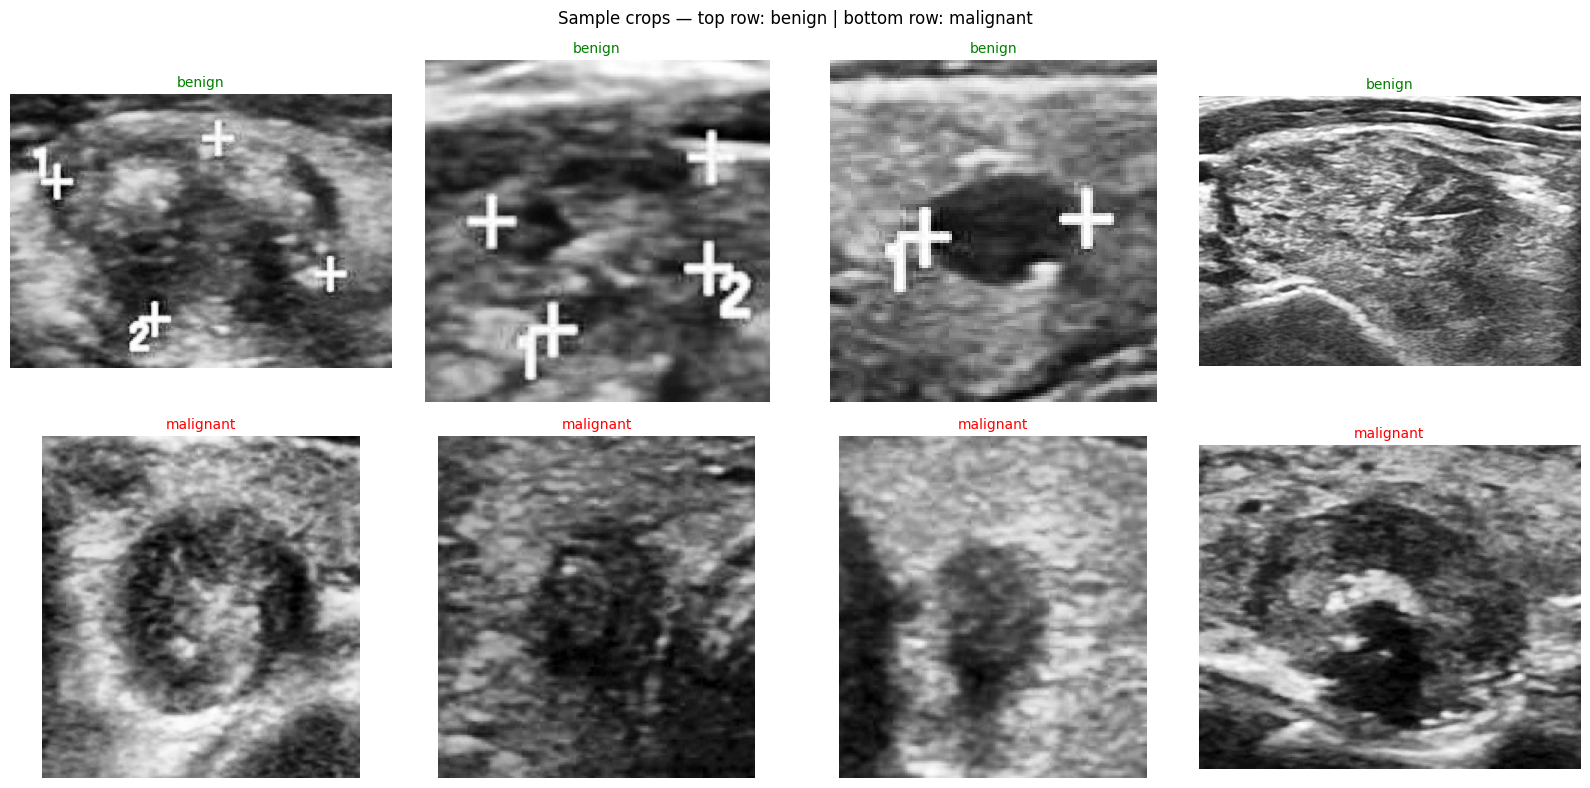

In [9]:
# ── Verify crops look correct ──────────────────────────────────────────────
sample = tv_df.groupby("label").apply(lambda g: g.sample(4, random_state=42)).reset_index(drop=True)
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, (_, row) in zip(axes.flatten(), sample.iterrows()):
    img = Image.open(os.path.join(CROP_DIR, row["filename"])).convert("RGB")
    ax.imshow(img); ax.axis("off")
    ax.set_title(CLASS_NAMES[row["label"]], fontsize=10,
                 color="red" if row["label"] == 1 else "green")
plt.suptitle("Sample crops — top row: benign | bottom row: malignant", fontsize=12)
plt.tight_layout(); plt.show()

In [17]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

train_transform = T.Compose([
    T.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomVerticalFlip(p=0.3),
    T.RandomRotation(degrees=20),
    T.ColorJitter(brightness=0.4, contrast=0.4, saturation=0.1), 
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.GaussianBlur(kernel_size=3, sigma=(0.1, 1.5)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),

    T.RandomErasing(p=0.3, scale=(0.02, 0.15), ratio=(0.3, 3.3)),
])

val_transform = T.Compose([
    T.Resize((RESIZE_SIZE, RESIZE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


tta_transform = T.Compose([
    T.Resize((RESIZE_SIZE + 32, RESIZE_SIZE + 32)),  
    T.FiveCrop(RESIZE_SIZE),
    T.Lambda(lambda crops: torch.stack([
        T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)(T.ToTensor()(c))
        for c in crops
    ])),
])

In [18]:
class ThyroidCropDataset(Dataset):
    def __init__(self, df, transform=None):
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row     = self.df.iloc[idx]
        img     = Image.open(os.path.join(CROP_DIR, row["filename"])).convert("RGB")
        label   = int(row["label"])
        if self.transform:
            img = self.transform(img)
        return img, label

In [37]:
def build_resnet50():
   
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V2)
    first_weight = model.layer1[0].conv1.weight.data[0, 0, 0, 0].item()
    print(f"  Weight check (should not be ~0): {first_weight:.6f}")

    # ── Step 1: Freeze everything ──────────────────────────────────────────
    for param in model.parameters():
        param.requires_grad = False

    # ── Step 2: Unfreeze only layer4 ──────────────────────────────────────
    for param in model.layer4.parameters():
        param.requires_grad = True

    # ── Step 3: Replace classifier head ───────────────────────────────────
    num_features = model.fc.in_features   # 2048 for ResNet-50
    model.fc = nn.Sequential(
        nn.Linear(num_features, 512),
        nn.ReLU(inplace=True),
        nn.Dropout(p=0.3),          # KEY regulariser — was missing in DenseNet
        nn.Linear(512, NUM_CLASSES)
    )
    # New head is unfrozen by default (nn.Sequential has requires_grad=True)

    model = model.to(DEVICE)

    # ── Print parameter summary ────────────────────────────────────────────
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"ResNet-50 loaded")
    print(f"  Total params    : {total:,}")
    print(f"  Trainable params: {trainable:,}  ({trainable/total*100:.1f}%)")
    print(f"  Frozen params   : {total-trainable:,}  ({(total-trainable)/total*100:.1f}%)")
    print(f"  Unfrozen layers : layer4 + new FC head")
    return model

In [31]:
def run_epoch(model, loader, criterion, optimizer, mode, epoch, num_epochs):
    is_train = (mode == "train")
    model.train() if is_train else model.eval()

    total_loss, correct, total = 0.0, 0, 0
    desc = f"  {'Train' if is_train else 'Val  '} Ep {epoch:02d}/{num_epochs}"

    with torch.set_grad_enabled(is_train):
        bar = tqdm(loader, desc=desc, leave=False, ncols=90)
        for imgs, labels in bar:
            imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
            out  = model(imgs)
            loss = criterion(out, labels)

            if is_train:
                optimizer.zero_grad()
                loss.backward()
                # CHANGE: Gradient clipping — prevents exploding gradients
                # during layer4 fine-tuning. Value of 1.0 is standard.
                torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
                optimizer.step()

            total_loss += loss.item() * labels.size(0)
            preds       = out.argmax(dim=1)
            correct    += (preds == labels).sum().item()
            total      += labels.size(0)
            bar.set_postfix(loss=f"{loss.item():.4f}")

    return total_loss / total, correct / total

In [38]:
NUM_EPOCHS=20
def train_kfold(tv_df):
    skf          = StratifiedKFold(n_splits=K_FOLDS, shuffle=True, random_state=42)
    fold_results = []

    for fold, (tr_idx, vl_idx) in enumerate(
            skf.split(tv_df, tv_df["label"]), start=1):
        print(f"\n{'='*60}")
        print(f"  FOLD {fold}/{K_FOLDS}")
        print(f"{'='*60}")

        # ── Clean state between folds ──────────────────────────────────────
        torch.cuda.empty_cache()
        torch.manual_seed(42 + fold)
        np.random.seed(42 + fold)
        random.seed(42 + fold)

        tr_df = tv_df.iloc[tr_idx]
        vl_df = tv_df.iloc[vl_idx]

        tr_ds = ThyroidCropDataset(tr_df, transform=train_transform)
        vl_ds = ThyroidCropDataset(vl_df, transform=val_transform)
        tr_ld = DataLoader(tr_ds, batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=NUM_WORKERS, pin_memory=True)
        vl_ld = DataLoader(vl_ds, batch_size=BATCH_SIZE, shuffle=False,
                           num_workers=NUM_WORKERS, pin_memory=True)

        model = build_resnet50()
        counts = np.bincount(tr_df["label"].values)
        cw = torch.tensor([(counts[1] / counts[0]) * 2.5, 1.0], dtype=torch.float32).to(DEVICE)
        criterion = nn.CrossEntropyLoss(weight=cw)

        optimizer = optim.AdamW([
            # layer4 — already adapted, train carefully
            {'params': model.layer4.parameters(),
             'lr': LR * 0.1},          # 3e-5 — 10x smaller than head
        
            # FC head — freshly initialised, needs to learn fast
            {'params': model.fc.parameters(),
             'lr': LR},                 # 3e-4 — full LR
        ],
        weight_decay=WEIGHT_DECAY)

        scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
            optimizer, mode='max', factor=0.5,
            patience=3, min_lr=1e-6,
        )

        best_macro_f1 = 0.0
        patience_ctr  = 0
        train_losses, val_losses = [], []
        train_accs,   val_accs   = [], []
        best_epoch    = 0

        for epoch in range(1, NUM_EPOCHS + 1):
            tr_loss, tr_acc = run_epoch(model, tr_ld, criterion, optimizer,
                                        "train", epoch, NUM_EPOCHS)
            vl_loss, vl_acc = run_epoch(model, vl_ld, criterion, optimizer,
                                        "val",   epoch, NUM_EPOCHS)

            train_losses.append(tr_loss); val_losses.append(vl_loss)
            train_accs.append(tr_acc);   val_accs.append(vl_acc)

            # ── Compute macro F1 first ─────────────────────────────────────
            model.eval()
            all_preds, all_labels = [], []
            with torch.no_grad():
                for imgs, labels in vl_ld:
                    imgs = imgs.to(DEVICE)
                    preds = model(imgs).argmax(dim=1)
                    all_preds.extend(preds.cpu().numpy())
                    all_labels.extend(labels.numpy())

            macro_f1     = f1_score(all_labels, all_preds, average="macro", zero_division=0)
            benign_f1    = f1_score(all_labels, all_preds, pos_label=0, zero_division=0)
            malignant_f1 = f1_score(all_labels, all_preds, pos_label=1, zero_division=0)

            # ── Step scheduler with macro_f1 ──────────────────────────────
            scheduler.step(macro_f1)

            flag = ""
            if macro_f1 > best_macro_f1:
                best_macro_f1 = macro_f1
                best_epoch    = epoch
                patience_ctr  = 0
                torch.save(model.state_dict(),
                           os.path.join(SAVE_DIR, f"best_resnet50_fold{fold}.pth"))
                flag = " ✓ saved"
            else:
                patience_ctr += 1

            current_lr = optimizer.param_groups[0]['lr']
            print(f"  Epoch [{epoch:02d}/{NUM_EPOCHS}]  "
                  f"Train Loss: {tr_loss:.4f}  Acc: {tr_acc:.4f}  |  "
                  f"Val Loss: {vl_loss:.4f}  Acc: {vl_acc:.4f}  "
                  f"BenF1: {benign_f1:.3f}  MalF1: {malignant_f1:.3f}  "
                  f"MacroF1: {macro_f1:.3f}  LR: {current_lr:.6f}{flag}")

            if patience_ctr >= PATIENCE:
                print(f"  Early stopping at epoch {epoch} "
                      f"(best epoch: {best_epoch}, best macro F1: {best_macro_f1:.4f})")
                break

        fold_results.append({
            "fold"          : fold,
            "train_losses"  : train_losses,
            "val_losses"    : val_losses,
            "train_accs"    : train_accs,
            "val_accs"      : val_accs,
            "best_macro_f1" : best_macro_f1,
            "best_epoch"    : best_epoch,
        })

    return fold_results

In [39]:
fold_results = train_kfold(tv_df)


  FOLD 1/3
  Weight check (should not be ~0): 0.097593
ResNet-50 loaded
  Total params    : 24,558,146
  Trainable params: 16,014,850  (65.2%)
  Frozen params   : 8,543,296  (34.8%)
  Unfrozen layers : layer4 + new FC head


  Epoch [01/20]  Train Loss: 0.5664  Acc: 0.3830  |  Val Loss: 0.5005  Acc: 0.4753  BenF1: 0.507  MalF1: 0.439  MacroF1: 0.473  LR: 0.000030 ✓ saved


  Epoch [02/20]  Train Loss: 0.4850  Acc: 0.5724  |  Val Loss: 0.4714  Acc: 0.6507  BenF1: 0.585  MalF1: 0.699  MacroF1: 0.642  LR: 0.000030 ✓ saved


  Epoch [03/20]  Train Loss: 0.4492  Acc: 0.6377  |  Val Loss: 0.4702  Acc: 0.7466  BenF1: 0.644  MalF1: 0.803  MacroF1: 0.724  LR: 0.000030 ✓ saved


  Epoch [04/20]  Train Loss: 0.4415  Acc: 0.6808  |  Val Loss: 0.4255  Acc: 0.7331  BenF1: 0.649  MalF1: 0.785  MacroF1: 0.717  LR: 0.000030


...

  Epoch [16/20]  Train Loss: 0.3448  Acc: 0.7780  |  Val Loss: 0.3740  Acc: 0.8222  BenF1: 0.734  MalF1: 0.866  MacroF1: 0.800  LR: 0.000015


  Epoch [17/20]  Train Loss: 0.3351  Acc: 0.7908  |  Val Loss: 0.3806  Acc: 0.8237  BenF1: 0.736  MalF1: 0.868  MacroF1: 0.802  LR: 0.000015


  Epoch [18/20]  Train Loss: 0.3506  Acc: 0.7803  |  Val Loss: 0.3717  Acc: 0.8290  BenF1: 0.740  MalF1: 0.873  MacroF1: 0.806  LR: 0.000007


  Epoch [19/20]  Train Loss: 0.3433  Acc: 0.7912  |  Val Loss: 0.3901  Acc: 0.8395  BenF1: 0.748  MalF1: 0.882  MacroF1: 0.815  LR: 0.000007 ✓ saved


  Epoch [20/20]  Train Loss: 0.3448  Acc: 0.7934  |  Val Loss: 0.3658  Acc: 0.8110  BenF1: 0.724  MalF1: 0.856  MacroF1: 0.790  LR: 0.000007


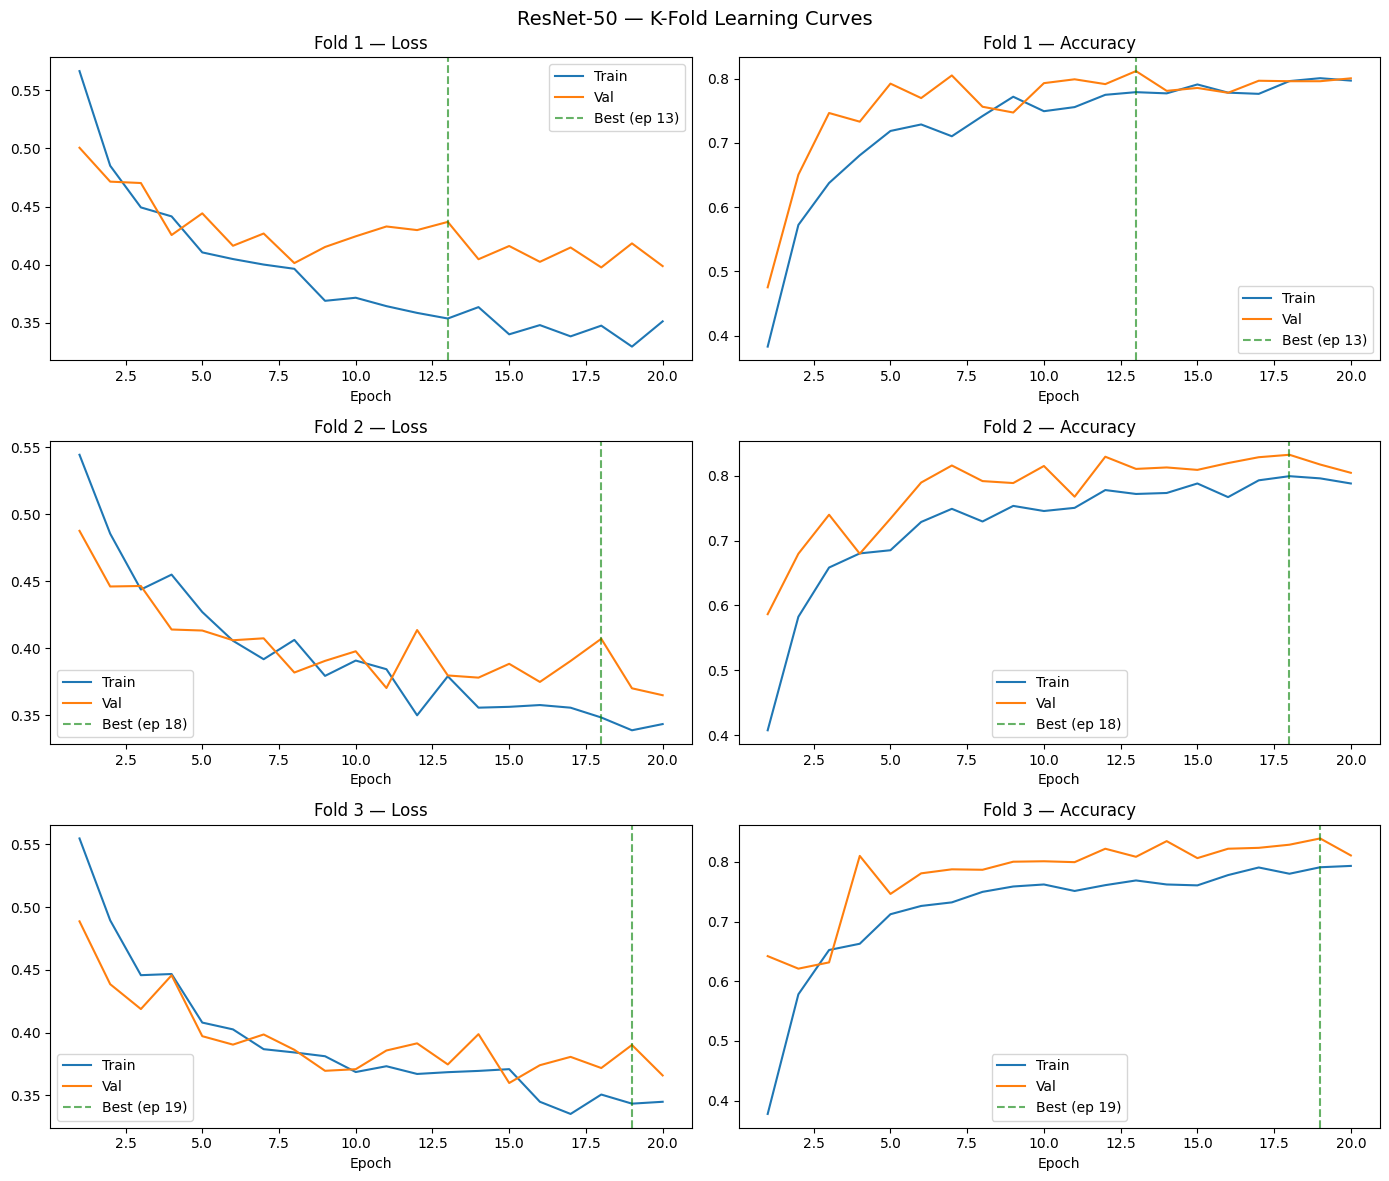

In [40]:
def plot_learning_curves(fold_results):
    fig, axes = plt.subplots(K_FOLDS, 2, figsize=(14, 4 * K_FOLDS))
    for i, res in enumerate(fold_results):
        ep = range(1, len(res["train_losses"]) + 1)
        axes[i, 0].plot(ep, res["train_losses"], label="Train")
        axes[i, 0].plot(ep, res["val_losses"],   label="Val")
        axes[i, 0].axvline(x=res["best_epoch"], color="g", linestyle="--",
                           alpha=0.6, label=f"Best (ep {res['best_epoch']})")
        axes[i, 0].set_title(f"Fold {res['fold']} — Loss")
        axes[i, 0].legend(); axes[i, 0].set_xlabel("Epoch")

        axes[i, 1].plot(ep, res["train_accs"], label="Train")
        axes[i, 1].plot(ep, res["val_accs"],   label="Val")
        axes[i, 1].axvline(x=res["best_epoch"], color="g", linestyle="--",
                           alpha=0.6, label=f"Best (ep {res['best_epoch']})")
        axes[i, 1].set_title(f"Fold {res['fold']} — Accuracy")
        axes[i, 1].legend(); axes[i, 1].set_xlabel("Epoch")

    plt.suptitle("ResNet-50 — K-Fold Learning Curves", fontsize=14)
    plt.tight_layout()
    plt.savefig("/kaggle/working/resnet_learning_curves.png", dpi=150)
    plt.show()

plot_learning_curves(fold_results)

In [41]:
def evaluate_test_tta(model_path, te_df):
    """
    Test-time augmentation (5-crop TTA).
    CHANGE from DenseNet: instead of single-pass inference, we run 5 crops
    (4 corners + centre) and average their softmax probabilities.
    WHY: This reduces variance in the prediction — a single crop can be
    unlucky with positioning. Averaging 5 crops costs 5x compute at inference
    but adds meaningful accuracy improvement with no retraining.
    """
    model = build_resnet50()
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    all_preds, all_labels, all_probs = [], [], []

    for _, row in tqdm(te_df.iterrows(), total=len(te_df), desc="TTA Inference"):
        img     = Image.open(os.path.join(CROP_DIR, row["filename"])).convert("RGB")
        label   = int(row["label"])
        crops   = tta_transform(img)   # shape: (5, 3, 224, 224)
        crops   = crops.to(DEVICE)

        with torch.no_grad():
            out    = model(crops)                    # (5, 2)
            probs  = torch.softmax(out, dim=1)       # (5, 2)
            avg_p  = probs.mean(dim=0)               # (2,)  — average over 5 crops
            pred   = avg_p.argmax().item()
            mal_p  = avg_p[1].item()

        all_preds.append(pred)
        all_labels.append(label)
        all_probs.append(mal_p)

    return np.array(all_labels), np.array(all_preds), np.array(all_probs)

# Use the fold with highest macro F1 (was lowest val_loss in DenseNet version)
best_fold = max(fold_results, key=lambda x: x["best_macro_f1"])["fold"]
best_path = os.path.join(SAVE_DIR, f"best_resnet50_fold{best_fold}.pth")
print(f"Using fold {best_fold} model  (best macro F1: "      f"{fold_results[best_fold-1]['best_macro_f1']:.4f})")

y_true, y_pred, y_prob = evaluate_test_tta(best_path, te_df)

Using fold 3 model  (best macro F1: 0.8152)
  Weight check (should not be ~0): 0.097593
ResNet-50 loaded
  Total params    : 24,558,146
  Trainable params: 16,014,850  (65.2%)
  Frozen params   : 8,543,296  (34.8%)
  Unfrozen layers : layer4 + new FC head


TTA Inference: 100%|██████████| 1000/1000 [00:20<00:00, 48.74it/s]



===== ResNet-50 Test Results (TTA) =====
              precision    recall  f1-score   support

      benign       0.59      0.84      0.69       269
   malignant       0.93      0.78      0.85       731

    accuracy                           0.80      1000
   macro avg       0.76      0.81      0.77      1000
weighted avg       0.84      0.80      0.81      1000

F1 (macro) : 0.7709
ROC-AUC    : 0.8953


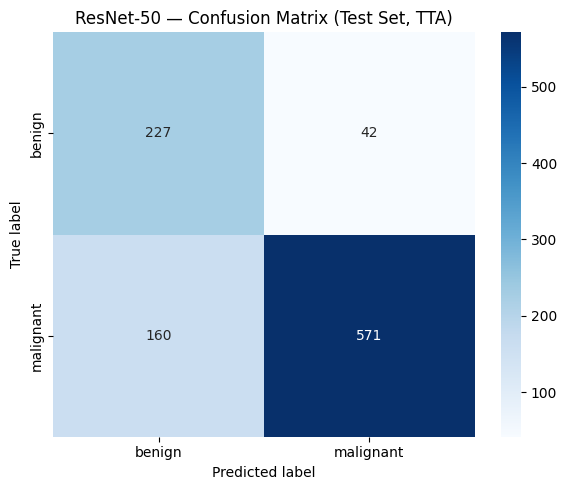

In [42]:
print("\n===== ResNet-50 Test Results (TTA) =====")
print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
print(f"F1 (macro) : {f1_score(y_true, y_pred, average='macro'):.4f}")
print(f"ROC-AUC    : {roc_auc_score(y_true, y_prob):.4f}")

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
ax.set_title("ResNet-50 — Confusion Matrix (Test Set, TTA)")
ax.set_ylabel("True label"); ax.set_xlabel("Predicted label")
plt.tight_layout()
plt.savefig("/kaggle/working/resnet_confusion_matrix.png", dpi=150)
plt.show()

In [43]:
# ── Threshold sweep: find clinically optimal threshold ─────────────────────
# CHANGE: Added explicit threshold sweep with clinical context.
# For biomedical use: missing a malignant case (FN) is far worse than
# a false alarm (FP). We want malignant recall >= 0.92.

print("\n===== Threshold Analysis =====")
print(f"{'Threshold':>10}  {'Ben-Prec':>9}  {'Ben-Rec':>8}  {'Mal-Prec':>9}  "      f"{'Mal-Rec':>8}  {'Macro-F1':>9}  {'Missed':>7}")
print("-" * 75)

for thresh in [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60]:
    yp = (y_prob >= thresh).astype(int)
    from sklearn.metrics import precision_recall_fscore_support
    p, r, f, _ = precision_recall_fscore_support(y_true, yp, zero_division=0)
    mf1 = f1_score(y_true, yp, average="macro", zero_division=0)
    missed = int((y_true == 1).sum()) - int(((yp == 1) & (y_true == 1)).sum())
    marker = " ← recommended" if 0.45 <= thresh <= 0.50 else ""
    print(f"  {thresh:.2f}       {p[0]:.3f}      {r[0]:.3f}     {p[1]:.3f}      "          f"{r[1]:.3f}     {mf1:.3f}    {missed:5d}{marker}")


===== Threshold Analysis =====
 Threshold   Ben-Prec   Ben-Rec   Mal-Prec   Mal-Rec   Macro-F1   Missed
---------------------------------------------------------------------------
  0.30       0.679      0.762     0.908      0.867     0.803       97
  0.35       0.661      0.784     0.915      0.852     0.800      108
  0.40       0.636      0.807     0.921      0.830     0.792      124
  0.45       0.615      0.825     0.926      0.810     0.784      139 ← recommended
  0.50       0.587      0.844     0.931      0.781     0.771      160 ← recommended
  0.55       0.562      0.855     0.934      0.755     0.757      179
  0.60       0.534      0.870     0.938      0.721     0.739      204



===== Results at threshold = 0.45 =====
              precision    recall  f1-score   support

      benign       0.61      0.83      0.70       269
   malignant       0.93      0.81      0.86       731

    accuracy                           0.81      1000
   macro avg       0.77      0.82      0.78      1000
weighted avg       0.84      0.81      0.82      1000

F1 (macro) : 0.7845
ROC-AUC    : 0.8953

Missed malignant (FN) : 139  (19.0% miss rate)
False alarms (FP)     : 47  (17.5% false alarm rate)


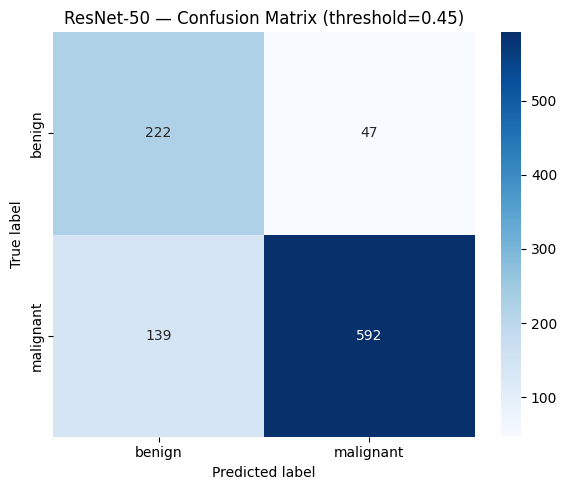


===== Results at threshold = 0.4 =====
              precision    recall  f1-score   support

      benign       0.64      0.81      0.71       269
   malignant       0.92      0.83      0.87       731

    accuracy                           0.82      1000
   macro avg       0.78      0.82      0.79      1000
weighted avg       0.84      0.82      0.83      1000

F1 (macro) : 0.7924
ROC-AUC    : 0.8953

Missed malignant (FN) : 124  (17.0% miss rate)
False alarms (FP)     : 52  (19.3% false alarm rate)


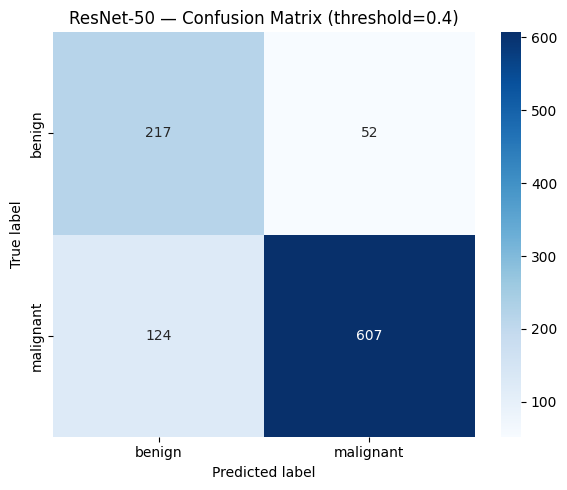


===== Results at threshold = 0.35 =====
              precision    recall  f1-score   support

      benign       0.66      0.78      0.72       269
   malignant       0.91      0.85      0.88       731

    accuracy                           0.83      1000
   macro avg       0.79      0.82      0.80      1000
weighted avg       0.85      0.83      0.84      1000

F1 (macro) : 0.8001
ROC-AUC    : 0.8953

Missed malignant (FN) : 108  (14.8% miss rate)
False alarms (FP)     : 58  (21.6% false alarm rate)


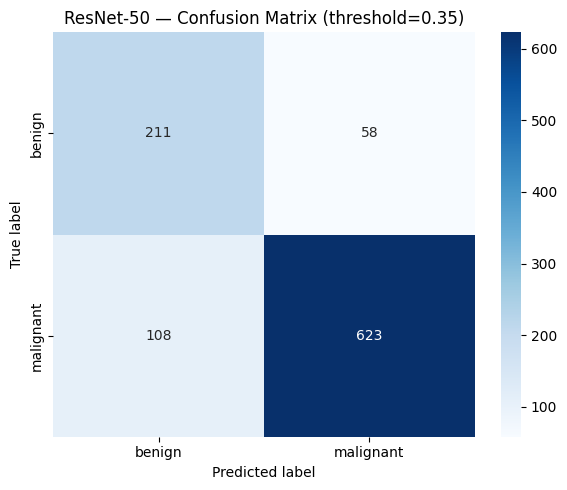


===== Results at threshold = 0.25 =====
              precision    recall  f1-score   support

      benign       0.71      0.72      0.71       269
   malignant       0.90      0.89      0.89       731

    accuracy                           0.84      1000
   macro avg       0.80      0.80      0.80      1000
weighted avg       0.84      0.84      0.84      1000

F1 (macro) : 0.8026
ROC-AUC    : 0.8953

Missed malignant (FN) : 80  (10.9% miss rate)
False alarms (FP)     : 76  (28.3% false alarm rate)


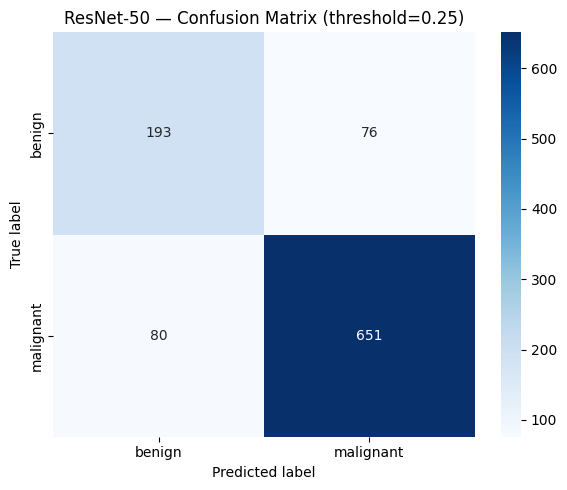

In [51]:
def plot_confusion_at_threshold(y_true, y_prob, threshold):
    y_pred = (y_prob >= threshold).astype(int)
    
    cm = confusion_matrix(y_true, y_pred)
    
    # ── Metrics ────────────────────────────────────────────────────────
    print(f"\n===== Results at threshold = {threshold} =====")
    print(classification_report(y_true, y_pred, target_names=CLASS_NAMES))
    print(f"F1 (macro) : {f1_score(y_true, y_pred, average='macro'):.4f}")
    print(f"ROC-AUC    : {roc_auc_score(y_true, y_prob):.4f}")
    
    tn, fp, fn, tp = cm.ravel()
    print(f"\nMissed malignant (FN) : {fn}  ({fn/sum(y_true==1)*100:.1f}% miss rate)")
    print(f"False alarms (FP)     : {fp}  ({fp/sum(y_true==0)*100:.1f}% false alarm rate)")
    
    # ── Confusion matrix plot ──────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=CLASS_NAMES, yticklabels=CLASS_NAMES, ax=ax)
    ax.set_title(f"ResNet-50 — Confusion Matrix (threshold={threshold})")
    ax.set_ylabel("True label")
    ax.set_xlabel("Predicted label")
    plt.tight_layout()
    plt.savefig(f"/kaggle/working/resnet_cm_thresh{str(threshold).replace('.','')}.png", dpi=150)
    plt.show()

# ── Run for both thresholds ────────────────────────────────────────────────
plot_confusion_at_threshold(y_true, y_prob, threshold=0.45)
plot_confusion_at_threshold(y_true, y_prob, threshold=0.40)
plot_confusion_at_threshold(y_true, y_prob, threshold=0.35)
plot_confusion_at_threshold(y_true, y_prob, threshold=0.25)

  Weight check (should not be ~0): 0.097593
ResNet-50 loaded
  Total params    : 24,558,146
  Trainable params: 16,014,850  (65.2%)
  Frozen params   : 8,543,296  (34.8%)
  Unfrozen layers : layer4 + new FC head


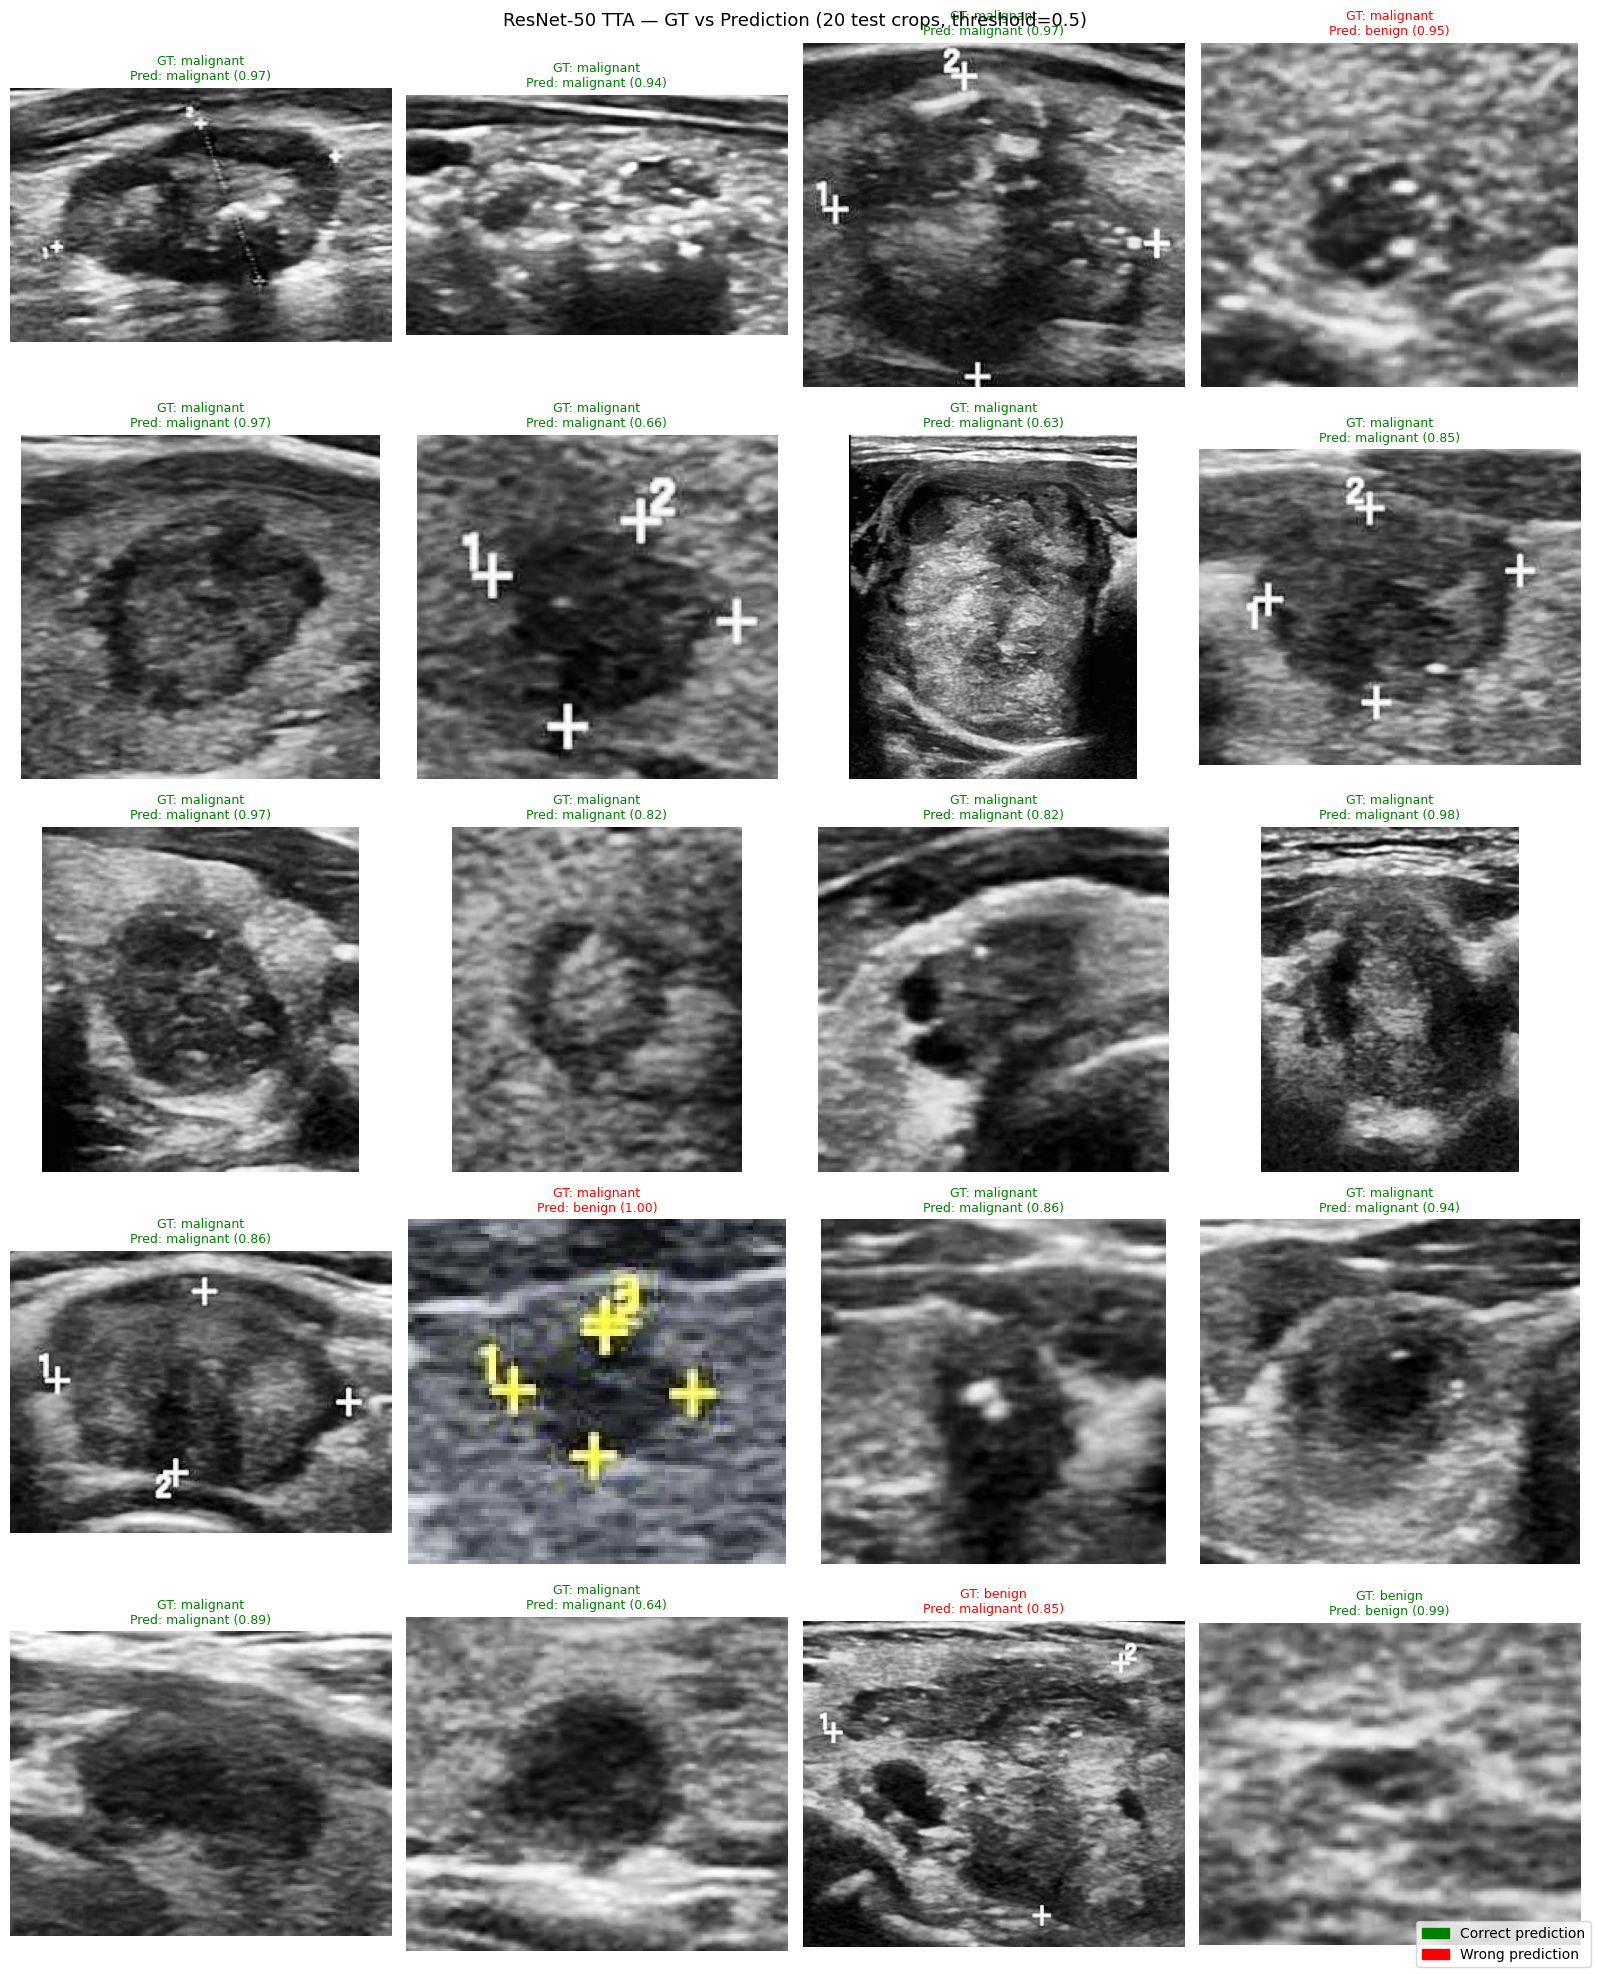

In [48]:
def show_gt_vs_pred(model_path, te_df, threshold=0.30, n=20):
    model = build_resnet50()
    model.load_state_dict(torch.load(model_path, map_location=DEVICE))
    model.eval()

    sample = te_df.sample(n, random_state=7).reset_index(drop=True)
    cols   = 4
    rows   = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(16, 4 * rows))
    axes = axes.flatten()

    for i, row in sample.iterrows():
        img_pil = Image.open(os.path.join(CROP_DIR, row["filename"])).convert("RGB")
        crops   = tta_transform(img_pil).to(DEVICE)

        with torch.no_grad():
            out  = model(crops)
            probs = torch.softmax(out, dim=1).mean(dim=0)
            pred  = int(probs[1].item() >= threshold)
            conf  = probs[pred].item()

        gt_name   = CLASS_NAMES[int(row["label"])]
        pred_name = CLASS_NAMES[pred]
        correct   = (pred == int(row["label"]))
        color     = "green" if correct else "red"

        axes[i].imshow(img_pil)
        axes[i].set_title(f"GT: {gt_name}\nPred: {pred_name} ({conf:.2f})",
                          fontsize=9, color=color)
        axes[i].axis("off")

    for j in range(i + 1, len(axes)):
        axes[j].axis("off")

    gt_patch  = mpatches.Patch(color="green", label="Correct prediction")
    err_patch = mpatches.Patch(color="red",   label="Wrong prediction")
    fig.legend(handles=[gt_patch, err_patch], loc="lower right", fontsize=10)
    plt.suptitle(f"ResNet-50 TTA — GT vs Prediction (20 test crops, threshold={threshold})",
                 fontsize=13)
    plt.tight_layout()
    plt.savefig("/kaggle/working/resnet_gt_vs_pred.png", dpi=150)
    plt.show()

show_gt_vs_pred(best_path, te_df, threshold=0.50)

In [49]:
# ── Cross-validation summary ────────────────────────────────────────────────
print("\n===== K-Fold Summary =====")
print(f"{'Fold':>5}  {'Best Epoch':>10}  {'Best Macro F1':>14}")
print("-" * 35)
for r in fold_results:
    print(f"  {r['fold']:>3}    {r['best_epoch']:>8}     {r['best_macro_f1']:.4f}")
avg = np.mean([r['best_macro_f1'] for r in fold_results])
print(f"\n  Mean macro F1 across folds: {avg:.4f}")


===== K-Fold Summary =====
 Fold  Best Epoch   Best Macro F1
-----------------------------------
    1          13     0.7837
    2          18     0.8061
    3          19     0.8152

  Mean macro F1 across folds: 0.8017
